In [1]:
!pip install -q requests beautifulsoup4 lxml pandas

import requests
from bs4 import BeautifulSoup
import json
import re
import time
import pandas as pd

BASE_URL = "https://scrapingsandbox.com"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (CodeAlpha-Internship-Scraper/1.0; educational use)"
}

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
def extract_product_json(html: str):
    """Extract the embedded product JSON object from a Scraping Sandbox product page."""
    soup = BeautifulSoup(html, "lxml")

    # 1) Preferred: the JSON is shown inside a <pre>/<code> block on the page
    for tag in soup.find_all(["pre", "code"]):
        text = tag.get_text(strip=True)
        if text.startswith("{") and '"sku"' in text:
            try:
                return json.loads(text)
            except json.JSONDecodeError:
                continue

    # 2) Fallback: regex-extract a JSON object starting with {"id": ...}
    match = re.search(r'\{\s*"id"\s*:\s*\d+.*?"variants"\s*:\s*\[.*?\]\s*\}', html, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            return None

    return None


def scrape_product(product_id: int, session: requests.Session, retries: int = 2):
    """Fetch and parse a single product page. Returns a dict or None if it fails/doesn't exist."""
    url = f"{BASE_URL}/product/{product_id}"
    for attempt in range(retries + 1):
        try:
            resp = session.get(url, headers=HEADERS, timeout=15)
            if resp.status_code == 404:
                return None
            resp.raise_for_status()
            data = extract_product_json(resp.text)
            if data:
                data["source_url"] = url
            return data
        except requests.exceptions.RequestException:
            if attempt == retries:
                return None
            time.sleep(1.5)
    return None


print("Scraper functions ready.")

Scraper functions ready.


In [3]:
N_PRODUCTS = 500
records = []
failed_ids = []

session = requests.Session()

for pid in range(1, N_PRODUCTS + 1):
    product = scrape_product(pid, session)
    if product:
        records.append(product)
    else:
        failed_ids.append(pid)

    if pid % 50 == 0:
        print(f"Scraped {pid}/{N_PRODUCTS} product pages...")

    time.sleep(0.15)  # polite delay so we don't hammer the server

print(f"\nDone. Successfully scraped {len(records)} products. Failed/missing IDs: {failed_ids}")

# Flatten into a tidy DataFrame
df = pd.DataFrame(records)
df["tags"] = df["tags"].apply(lambda t: ", ".join(t) if isinstance(t, list) else t)
df["variant_count"] = df["variants"].apply(lambda v: len(v) if isinstance(v, list) else 0)
df = df.drop(columns=["variants"])

df.to_csv("products.csv", index=False)
print("Saved products.csv with", len(df), "rows and", df.shape[1], "columns.")
df.head(10)

Scraped 50/500 product pages...
Scraped 100/500 product pages...
Scraped 150/500 product pages...
Scraped 200/500 product pages...
Scraped 250/500 product pages...
Scraped 300/500 product pages...
Scraped 350/500 product pages...
Scraped 400/500 product pages...
Scraped 450/500 product pages...
Scraped 500/500 product pages...

Done. Successfully scraped 500 products. Failed/missing IDs: []
Saved products.csv with 500 rows and 16 columns.


,id,title,vendor,category,price,compareAtPrice,description,image,tags,sku,inStock,rating,reviewCount,createdAt,source_url,variant_count
0,1,Lightweight Probiotics,SoundWave,Health,155.62,206.69,High-quality lightweight probiotics from Sound...,https://placehold.co/400x400/10b981/ffffff?tex...,"natural, fitness",SKU-HEA-0001,True,4.0,52,2022-08-29T00:00:00.000Z,https://scrapingsandbox.com/product/1,4
1,2,Wireless LED Desk Lamp,SoundWave,Electronics,145.40,210.01,High-quality wireless led desk lamp from Sound...,https://placehold.co/400x400/f59e0b/ffffff?tex...,"tech, digital, USB",SKU-ELE-0002,False,4.6,12,2023-06-04T00:00:00.000Z,https://scrapingsandbox.com/product/2,2
2,3,Deluxe Tea Collection,StyleCraft,Food & Beverage,185.01,313.98,High-quality deluxe tea collection from StyleC...,https://placehold.co/400x400/84cc16/ffffff?tex...,organic,SKU-FOO-0003,True,3.5,211,2023-04-17T00:00:00.000Z,https://scrapingsandbox.com/product/3,3
3,4,Essential Tire Gauge,TechVault,Automotive,70.86,NaN,High-quality essential tire gauge from TechVau...,https://placehold.co/400x400/6366f1/ffffff?tex...,"car, accessories, travel",SKU-AUT-0004,False,3.6,47,2022-10-24T00:00:00.000Z,https://scrapingsandbox.com/product/4,5
4,5,Smart Carving Tools,SparkleBox,Art,97.13,NaN,High-quality smart carving tools from SparkleB...,https://placehold.co/400x400/f59e0b/ffffff?tex...,"drawing, painting",SKU-ART-0005,True,3.5,353,2022-08-07T00:00:00.000Z,https://scrapingsandbox.com/product/5,5
5,6,Professional Dog Food,StyleCraft,Pet Supplies,145.40,NaN,High-quality professional dog food from StyleC...,https://placehold.co/400x400/ef4444/ffffff?tex...,"cats, grooming, food",SKU-PET-0006,True,4.6,156,2022-08-30T00:00:00.000Z,https://scrapingsandbox.com/product/6,4
6,7,Smart Car Wash Kit,UrbanThread,Automotive,139.94,173.26,High-quality smart car wash kit from UrbanThre...,https://placehold.co/400x400/84cc16/ffffff?tex...,car,SKU-AUT-0007,True,3.0,81,2023-08-19T00:00:00.000Z,https://scrapingsandbox.com/product/7,3
7,8,Premium Bluetooth Speaker,AutoParts Pro,Electronics,108.99,NaN,High-quality premium bluetooth speaker from Au...,https://placehold.co/400x400/06b6d4/ffffff?tex...,USB,SKU-ELE-0008,True,4.5,426,2023-09-04T00:00:00.000Z,https://scrapingsandbox.com/product/8,3
8,9,Vintage Tablet Stand,GlowUp,Electronics,44.15,69.14,High-quality vintage tablet stand from GlowUp....,https://placehold.co/400x400/f59e0b/ffffff?tex...,tech,SKU-ELE-0009,True,3.4,411,2023-10-16T00:00:00.000Z,https://scrapingsandbox.com/product/9,2
9,10,Portable Marker Pack,VitalLife,Art,193.91,258.48,High-quality portable marker pack from VitalLi...,https://placehold.co/400x400/3b82f6/ffffff?tex...,"supplies, creative, crafts",SKU-ART-0010,True,4.2,330,2023-10-27T00:00:00.000Z,https://scrapingsandbox.com/product/10,3


In [4]:
import pandas as pd
import numpy as np

# Reload from disk to simulate a fresh analysis session (also proves the CSV is self-contained)
df = pd.read_csv("products.csv")

print("Rows x Columns:", df.shape)
print()
df.info()

Rows x Columns: (500, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              500 non-null    int64  
 1   title           500 non-null    object 
 2   vendor          500 non-null    object 
 3   category        500 non-null    object 
 4   price           500 non-null    float64
 5   compareAtPrice  189 non-null    float64
 6   description     500 non-null    object 
 7   image           500 non-null    object 
 8   tags            500 non-null    object 
 9   sku             500 non-null    object 
 10  inStock         500 non-null    bool   
 11  rating          500 non-null    float64
 12  reviewCount     500 non-null    int64  
 13  createdAt       500 non-null    object 
 14  source_url      500 non-null    object 
 15  variant_count   500 non-null    int64  
dtypes: bool(1), float64(3), int64(3), object(9)
memory us

In [5]:
# --- Data quality checks -----------------------------------------------------

print("Missing values per column:")
print(df.isna().sum())

print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicate SKUs:", df['sku'].duplicated().sum())
print("Duplicate product IDs:", df['id'].duplicated().sum())

Missing values per column:
id                  0
title               0
vendor              0
category            0
price               0
compareAtPrice    311
description         0
image               0
tags                0
sku                 0
inStock             0
rating              0
reviewCount         0
createdAt           0
source_url          0
variant_count       0
dtype: int64

Fully duplicated rows: 0
Duplicate SKUs: 0
Duplicate product IDs: 0


In [6]:
# Descriptive statistics for all columns
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
title,500,485,Premium Omega-3 Capsules,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor,500,20,PageTurner,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,500,15,Electronics,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,500.0,NaN,NaN,NaN,104.10006,58.274374,5.12,55.305,105.23,152.625,204.86
compareAtPrice,189.0,NaN,NaN,NaN,161.359312,88.917038,7.76,80.02,175.37,237.51,330.47
description,500,499,High-quality advanced watch from FitPro. Perfe...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image,500,450,https://placehold.co/400x400/3b82f6/ffffff?tex...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,500,261,"fashion, streetwear, casual",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,500,500,SKU-PET-0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# compareAtPrice is only present for discounted items — missing values there are
# expected (no discount), not a data quality problem. Let's confirm and handle it cleanly.

df["is_discounted"] = df["compareAtPrice"].notna()
df["discount_amount"] = np.where(df["is_discounted"], df["compareAtPrice"] - df["price"], 0)
df["discount_pct"] = np.where(df["is_discounted"], (df["discount_amount"] / df["compareAtPrice"]) * 100, 0)

print(f"{df['is_discounted'].sum()} of {len(df)} products are currently discounted "
      f"({df['is_discounted'].mean():.1%}).")

print("\nNumber of unique categories:", df["category"].nunique())
print("Number of unique vendors:", df["vendor"].nunique())

category_counts = df["category"].value_counts()
vendor_counts = df["vendor"].value_counts()

print("\nProducts per category:\n", category_counts)

189 of 500 products are currently discounted (37.8%).

Number of unique categories: 15
Number of unique vendors: 20

Products per category:
 category
Electronics        44
Music              39
Food & Beverage    38
Clothing           37
Automotive         37
Office Supplies    36
Jewelry            36
Sports             34
Health             34
Books              30
Home & Garden      29
Art                28
Pet Supplies       28
Toys               26
Beauty             24
Name: count, dtype: int64


In [8]:
# Price & rating statistics by category
price_by_category = df.groupby("category")["price"].agg(["count", "mean", "median", "min", "max"]).sort_values("mean", ascending=False)
price_by_category.round(2)

,count,mean,median,min,max
category,,,,,
Home & Garden,29,126.70,146.35,7.55,195.03
Health,34,114.52,122.74,13.40,201.63
Beauty,24,110.31,120.32,5.12,202.59
Toys,26,107.96,113.40,12.00,175.94
Office Supplies,36,107.03,103.84,9.44,195.45
Food & Beverage,38,106.31,116.91,6.22,203.99
Music,39,105.93,107.29,7.77,203.13
Art,28,104.20,91.78,13.45,204.29
Jewelry,36,104.13,111.85,5.66,201.23


In [9]:
# --- Correlation between numeric variables -----------------------------------

numeric_cols = ["price", "compareAtPrice", "rating", "reviewCount", "discount_amount", "discount_pct", "variant_count"]
corr = df[numeric_cols].corr(numeric_only=True)
corr.round(2)

,price,compareAtPrice,rating,reviewCount,discount_amount,discount_pct,variant_count
price,1.00,0.98,0.05,0.03,0.40,0.09,0.04
compareAtPrice,0.98,1.00,0.05,-0.03,0.93,0.20,0.04
rating,0.05,0.05,1.00,-0.06,-0.08,-0.12,0.02
reviewCount,0.03,-0.03,-0.06,1.00,-0.03,-0.01,-0.05
discount_amount,0.40,0.93,-0.08,-0.03,1.00,0.83,0.02
discount_pct,0.09,0.20,-0.12,-0.01,0.83,1.00,0.00
variant_count,0.04,0.04,0.02,-0.05,0.02,0.00,1.00


In [10]:
# --- Outlier detection using the IQR method (on price) -----------------------

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Price IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of price outliers: {len(outliers)}")
outliers[["title", "category", "price"]].sort_values("price", ascending=False).head(10)

Price IQR bounds: [-90.67, 298.61]
Number of price outliers: 0


,title,category,price


In [11]:
# --- Stock status overview ----------------------------------------------------

stock_counts = df["inStock"].value_counts()
print("In-stock vs out-of-stock counts:")
print(stock_counts)
print(f"\nOut-of-stock rate: {(~df['inStock']).mean():.1%}")

# Save the enriched dataframe (with discount columns) so Task 3 can reuse it
df.to_csv("products_enriched.csv", index=False)

In-stock vs out-of-stock counts:
inStock
True     427
False     73
Name: count, dtype: int64

Out-of-stock rate: 14.6%


/tmp/ipykernel_845/2829759457.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


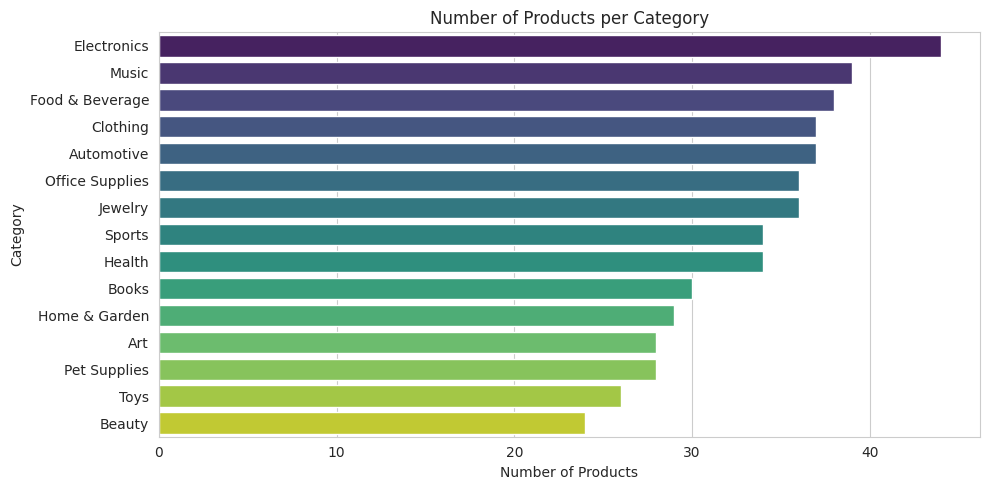

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# 1) Bar chart — number of products per category
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title("Number of Products per Category")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart_1_products_per_category.png", dpi=150)
plt.show()

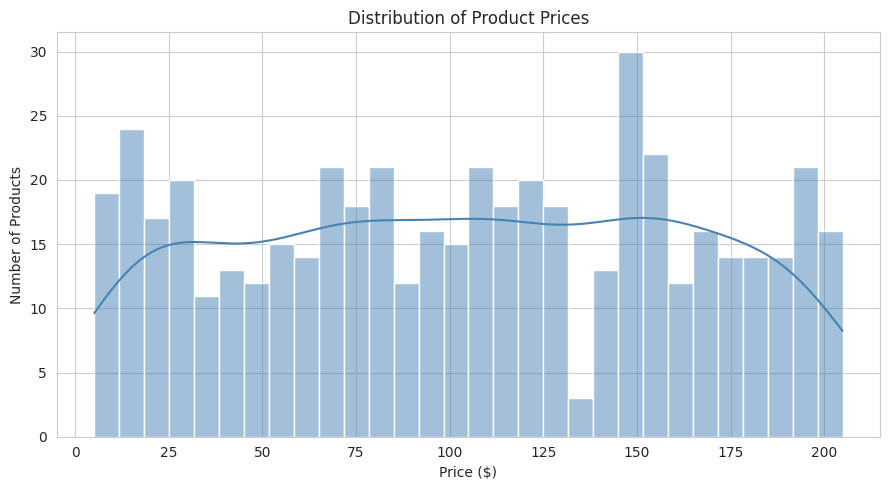

In [13]:
# 2) Histogram — price distribution
plt.figure()
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.savefig("chart_2_price_distribution.png", dpi=150)
plt.show()

/tmp/ipykernel_845/2747268126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="price", order=order, palette="coolwarm")


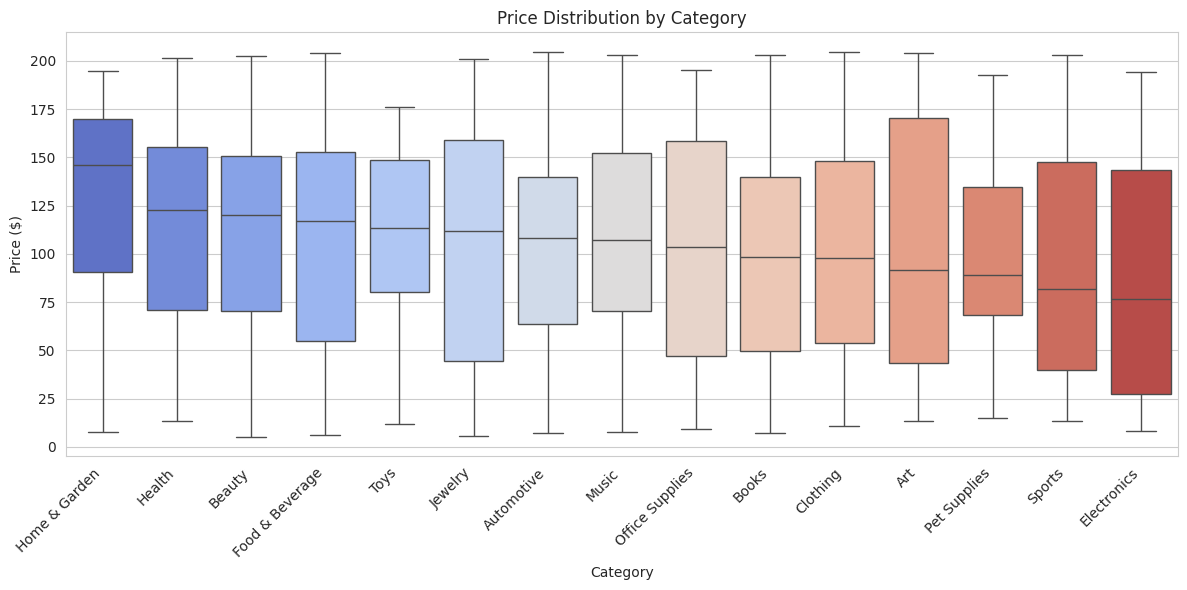

In [14]:
# 3) Boxplot — price spread by category (also visually confirms Task 2's IQR outliers)
plt.figure(figsize=(12, 6))
order = df.groupby("category")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="category", y="price", order=order, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("chart_3_price_by_category_boxplot.png", dpi=150)
plt.show()

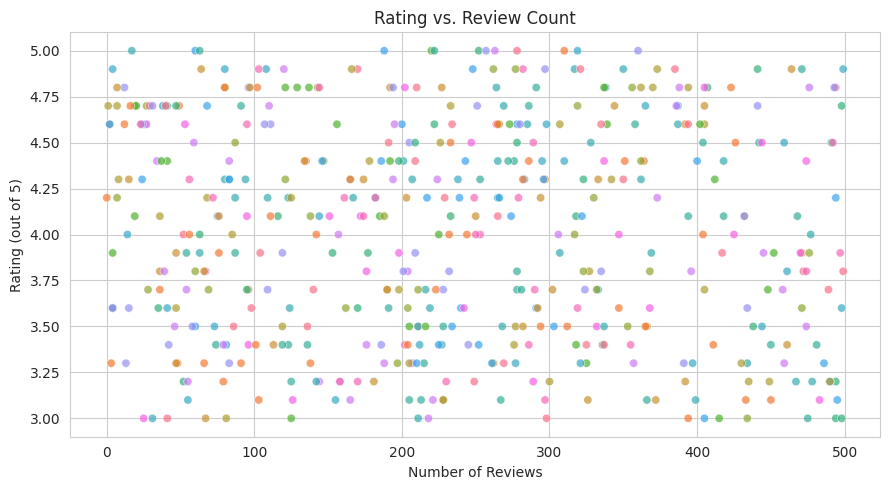

In [15]:
# 4) Scatter plot — rating vs. number of reviews (is popularity linked to rating?)
plt.figure()
sns.scatterplot(data=df, x="reviewCount", y="rating", hue="category", alpha=0.7, legend=False)
plt.title("Rating vs. Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating (out of 5)")
plt.tight_layout()
plt.savefig("chart_4_rating_vs_reviews.png", dpi=150)
plt.show()

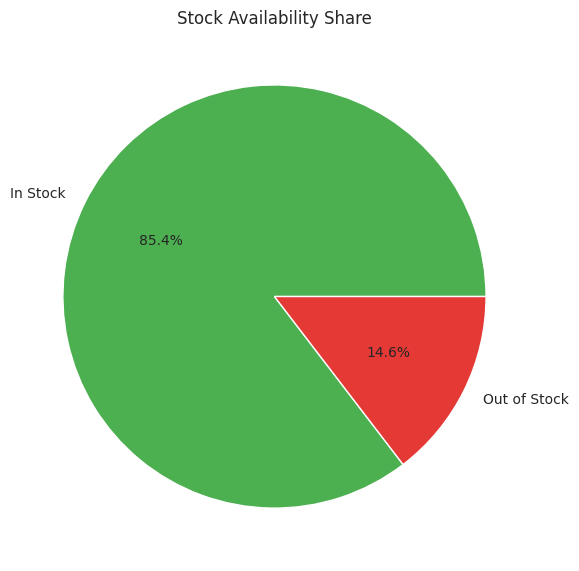

In [16]:
# 5) Pie chart — in-stock vs out-of-stock share
plt.figure(figsize=(6, 6))
stock_counts.plot.pie(autopct="%1.1f%%", labels=["In Stock", "Out of Stock"],
                       colors=["#4CAF50", "#E53935"], ylabel="")
plt.title("Stock Availability Share")
plt.tight_layout()
plt.savefig("chart_5_stock_status_pie.png", dpi=150)
plt.show()

/tmp/ipykernel_845/1644661012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors.values, y=top_vendors.index, palette="magma")


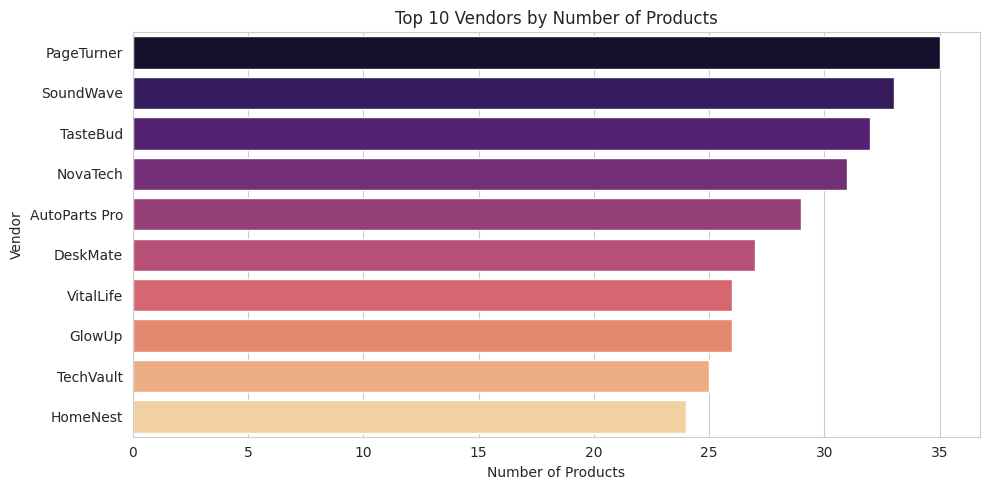

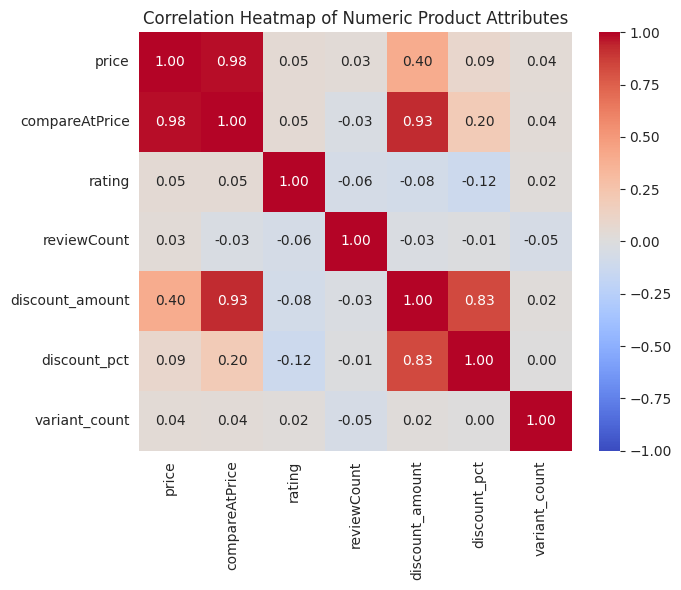

/tmp/ipykernel_845/1644661012.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount_by_cat.values, y=discount_by_cat.index, palette="crest")


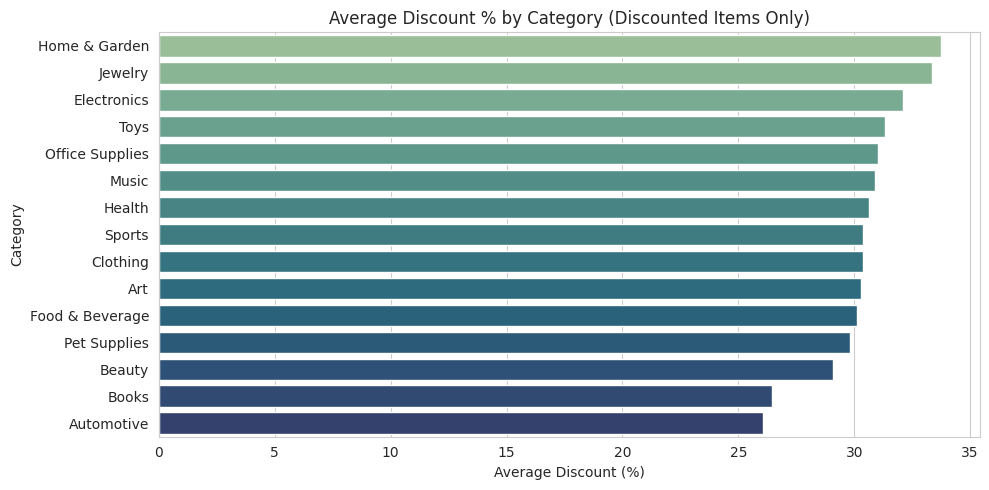

In [17]:
# 6) Bar chart — top 10 vendors by product count
plt.figure(figsize=(10, 5))
top_vendors = vendor_counts.head(10)
sns.barplot(x=top_vendors.values, y=top_vendors.index, palette="magma")
plt.title("Top 10 Vendors by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Vendor")
plt.tight_layout()
plt.savefig("chart_6_top_vendors.png", dpi=150)
plt.show()

# 7) Heatmap — correlation between numeric variables
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Product Attributes")
plt.tight_layout()
plt.savefig("chart_7_correlation_heatmap.png", dpi=150)
plt.show()

# 8) Discount depth by category — where are the biggest discounts?
discount_by_cat = df[df["is_discounted"]].groupby("category")["discount_pct"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=discount_by_cat.values, y=discount_by_cat.index, palette="crest")
plt.title("Average Discount % by Category (Discounted Items Only)")
plt.xlabel("Average Discount (%)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart_8_avg_discount_by_category.png", dpi=150)
plt.show()

In [20]:
import os
import zipfile
from google.colab import files

# Only zip the files this project actually created — not the whole /content folder
files_to_include = [
    "products.csv",
    "products_enriched.csv",
    "chart_1_products_per_category.png",
    "chart_2_price_distribution.png",
    "chart_3_price_by_category_boxplot.png",
    "chart_4_rating_vs_reviews.png",
    "chart_5_stock_status_pie.png",
    "chart_6_top_vendors.png",
    "chart_7_correlation_heatmap.png",
    "chart_8_avg_discount_by_category.png",
]

existing = [f for f in files_to_include if os.path.exists(f)]
missing = [f for f in files_to_include if not os.path.exists(f)]

print("Found and will zip:", existing)
if missing:
    print("⚠️ Missing — re-run the earlier cell(s) that create these:", missing)

zip_path = "/content/CodeAlpha_DataAnalytics_Submission.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in existing:
        zf.write(f)

print(f"\nCreated {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)")

Found and will zip: ['products.csv', 'products_enriched.csv', 'chart_1_products_per_category.png', 'chart_2_price_distribution.png', 'chart_3_price_by_category_boxplot.png', 'chart_4_rating_vs_reviews.png', 'chart_5_stock_status_pie.png', 'chart_6_top_vendors.png', 'chart_7_correlation_heatmap.png', 'chart_8_avg_discount_by_category.png']

Created /content/CodeAlpha_DataAnalytics_Submission.zip (1076.8 KB)
